## Notebook 2: Models
Expanding window training and validation for all 3 models: softmax regression, XGBoost, and neural network
Standard scaling refit and transformed on every window increase
Compares model preformance to 3 baselines: random guessing, momentum, and reversion

In [1]:
# imports
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
warnings.filterwarnings('ignore')
retrain = False # feature flag to activate training and predicting

if retrain:
    # load data
    df = pd.read_csv('../data/raw_master.csv')
    df.drop('Date', inplace=True, axis=1)
    rows = len(df)
    cols = len(df.columns)
    
    # Encode labels
    le = LabelEncoder()
    le.fit(df['label'])
    
    # Standard scaler - centers at 0 (mean = 0) with std = 1
    scaler = StandardScaler()
    
    # Predicted Value vs Target Label for each model
    results = {
        'Softmax Regression': {'preds': [], 'trues': []},
        'XGBoost':            {'preds': [], 'trues': []},
        'MLP Classifier':     {'preds': [], 'trues': []}
    }
    
    # expanding window loop
    for i in range(30, rows):
        # models
        models = {
            'Softmax Regression' : LogisticRegression(
                solver='lbfgs',      # Supports multinomial classification (softmax)
                penalty='l2',        # Default regularization type (L2 regularization)
                C=1.0                # Inverse regularization strength
            ),
            
            'XGBoost' : XGBClassifier(
                eval_metric='logloss', # log loss function
                random_state=42,
                n_estimators=50,
                max_depth=3,
                n_jobs=1
            ),
            
            'MLP Classifier' : MLPClassifier(
                alpha=0.1,
                hidden_layer_sizes=(50,), # 1 hidden layer with 50 neurons
                max_iter=200
            )
        }
    
        X_train = df.iloc[:i, :-1]
        X_test = df.iloc[[i], :-1]
        
        y_train = le.transform(df.iloc[:i, -1])
        y_test = le.transform(df.iloc[[i], -1])
    
        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    
        for name, model in models.items():
            model.fit(X_train_scaled, y_train)
            
            predicted = model.predict(X_test_scaled)
            
            results[name]['preds'].append(predicted)
            results[name]['trues'].append(y_test)
    
    with open('../data/results.pkl', 'wb') as f:
        pickle.dump(results, f)
else:
    with open('../data/results.pkl', 'rb') as f:
        results = pickle.load(f)
        
        df = pd.read_csv('../data/raw_master.csv')
        df.drop('Date', inplace=True, axis=1)

        le = LabelEncoder()
        le.fit(df['label'])

                    Accuracy  Weighted F1
Softmax Regression    0.1426       0.1409
XGBoost               0.1689       0.1523
MLP Classifier        0.1397       0.1365
--- Baselines ---        NaN          NaN
Random                0.1250          NaN
Momentum              0.1601          NaN
Reversion             0.1572          NaN


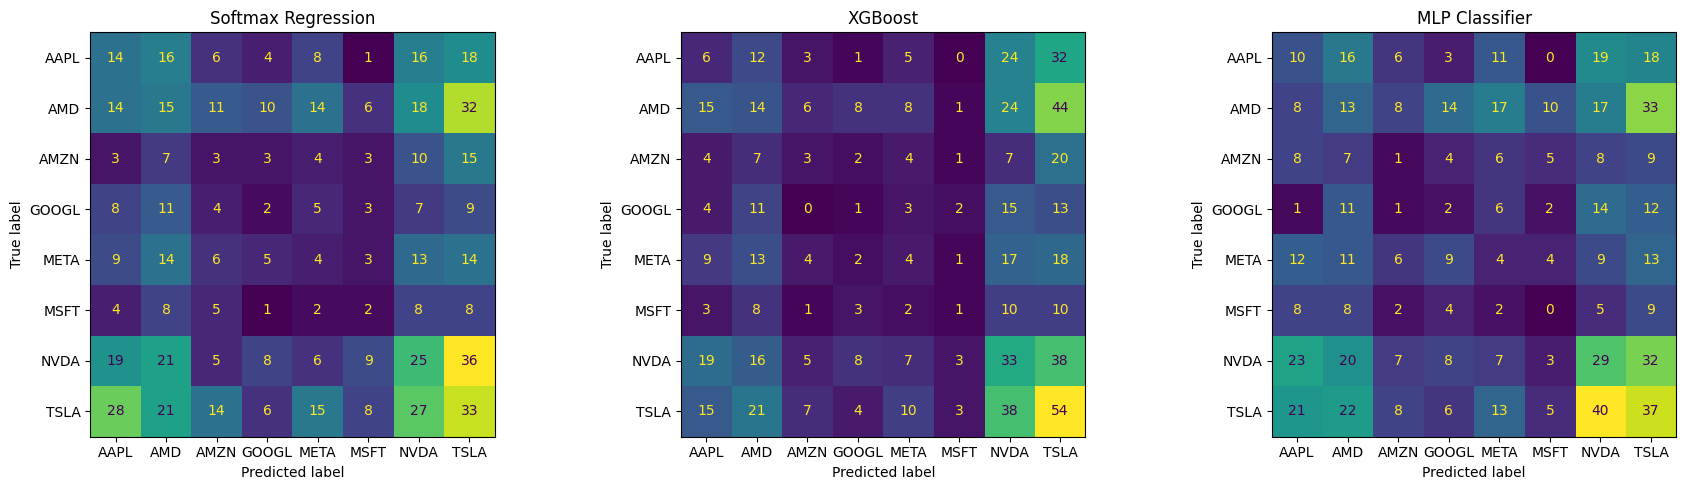

In [3]:
# ── Baseline Accuracies = Random, Momentum, and Reversion ──────────────────────────────────────────────────────────────────
close_df = df[df.columns[df.columns.str.contains('ret_1d')]]

# True labels as ticker strings (aligned to expanding window range)
true_tickers = df['label'].iloc[30:].reset_index(drop=True)
prev_returns = df[[c for c in df.columns if c.endswith('ret_1d')]].iloc[30:].reset_index(drop=True)
prev_returns.columns = [c.replace('_ret_1d', '') for c in prev_returns.columns]

momentum_preds  = prev_returns.idxmax(axis=1)
reversion_preds = prev_returns.idxmin(axis=1)

random_acc    = 1 / 8
momentum_acc  = accuracy_score(true_tickers, momentum_preds)
reversion_acc = accuracy_score(true_tickers, reversion_preds)

# ── Model Metrics ──────────────────────────────────────────────────────────────
metrics = {}
for name, data in results.items():
    preds = np.concatenate(data['preds'])
    trues = np.concatenate(data['trues'])
    metrics[name] = {
        'Accuracy': accuracy_score(trues, preds),
        'Weighted F1': f1_score(trues, preds, average='weighted')
    }

# ── Summary Table ──────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame(metrics).T
metrics_df.loc['--- Baselines ---'] = [np.nan, np.nan]
metrics_df.loc['Random']    = [random_acc,    np.nan]
metrics_df.loc['Momentum']  = [momentum_acc,  np.nan]
metrics_df.loc['Reversion'] = [reversion_acc, np.nan]

print(metrics_df.round(4))

# ── Confusion Matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, data) in zip(axes, results.items()):
    preds = np.concatenate(data['preds'])
    trues = np.concatenate(data['trues'])
    cm = confusion_matrix(trues, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()